In [1]:
#Import the necessary libraries

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')
plt.rcParams['figure.figsize']=6,6
plt.style.use('fivethirtyeight')
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn import metrics
import pickle
from sklearn.naive_bayes import GaussianNB
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

In [2]:
#Load the dataset

df=pd.read_csv('diabetes_prediction_dataset.csv')
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [3]:
#Number of rows and columns in the dataframe

df.shape

(100000, 9)

There are 96146 rows and 9 columns in the dataframe

In [4]:
#List any 5 lines of the dataframe

df.sample(5)

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
1138,Female,28.0,0,0,current,27.32,6.2,140,0
82515,Female,14.0,0,0,No Info,29.37,4.5,90,0
45142,Female,35.0,0,0,No Info,22.40,4.8,126,0
72487,Female,3.0,0,0,No Info,27.32,4.0,140,0
77439,Female,80.0,0,1,former,27.32,6.6,145,0


In [5]:
#Provide the statistical measure of the datafarme

df.describe().style.background_gradient()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.074850,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.263150,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.000000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.000000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.000000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.000000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.000000,1.000000,95.690000,9.000000,300.000000,1.000000


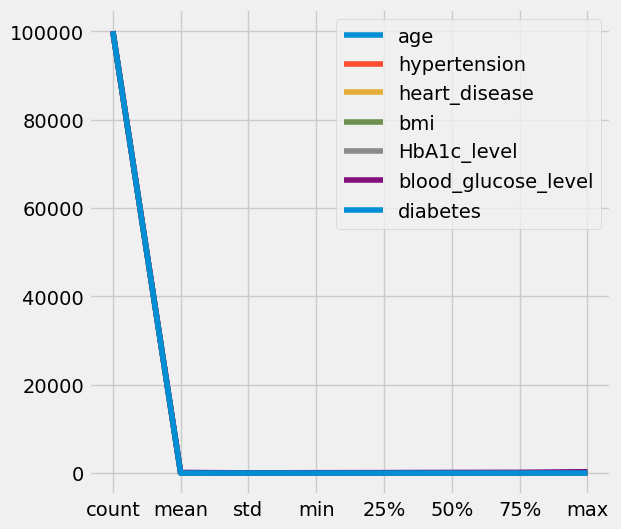

In [6]:
#Plot the statistical measure of the dataframe

df.describe().plot()
plt.show()

In [7]:
#Check for duplicated values

df.duplicated().sum()

3854

In [8]:
#Drop duplicate values of the dataset

df.drop_duplicates(inplace=True)

In [9]:
#Checking for null values

df.isna().sum()

gender                 0
age                    0
hypertension           0
heart_disease          0
smoking_history        0
bmi                    0
HbA1c_level            0
blood_glucose_level    0
diabetes               0
dtype: int64

There are no null values present in the dataset.

# Exploratory Data Analysis

### Scatter plot

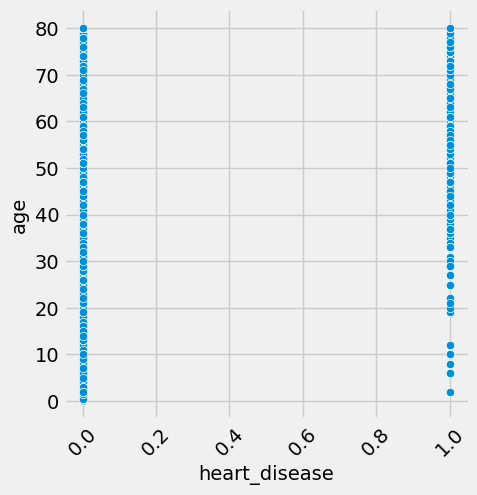

In [10]:
#Check the distribution of heart disease with respect to age

sns.relplot(x='heart_disease',y='age',data=df)
plt.xticks(rotation=45)
plt.show()

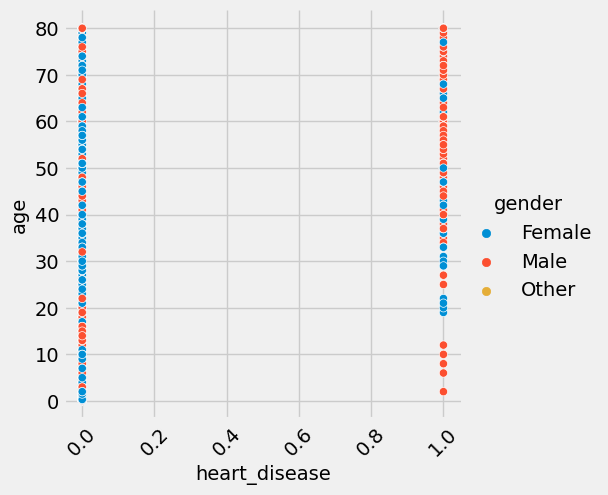

In [11]:
#Check the distribution of heart disease with respect to age

sns.relplot(x='heart_disease',y='age',hue='gender',data=df)
plt.xticks(rotation=45)
plt.show()

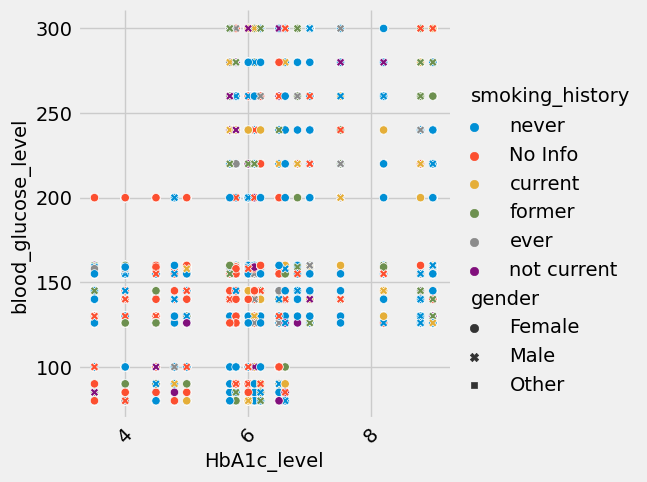

In [12]:
sns.relplot(x='HbA1c_level',y='blood_glucose_level',hue='smoking_history',style='gender',data=df)
plt.xticks(rotation=45)
plt.show()

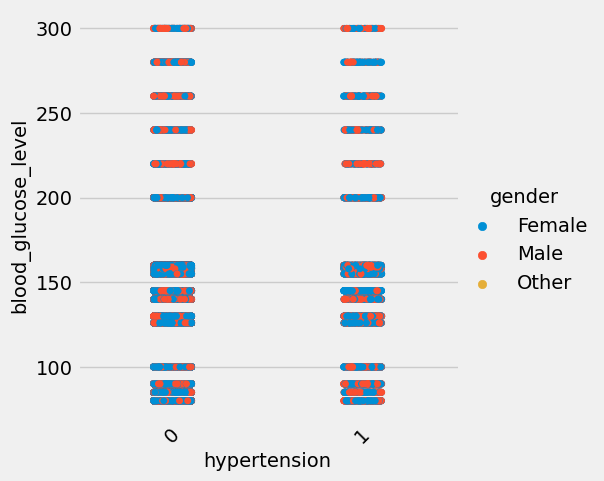

In [13]:
sns.catplot(y='blood_glucose_level',x='hypertension',hue='gender',data=df)
plt.xticks(rotation=45)
plt.show()

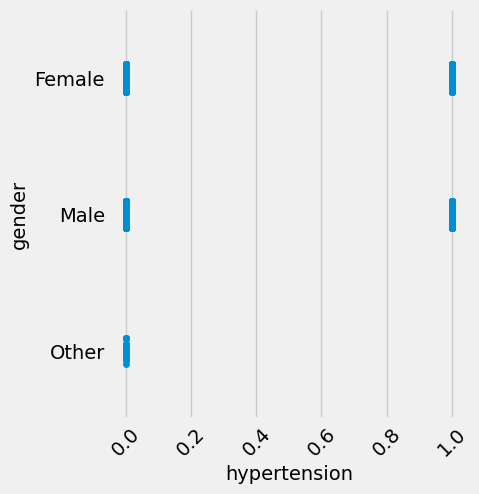

In [14]:
sns.catplot(x='hypertension',y='gender',data=df)
plt.xticks(rotation=45)
plt.show()

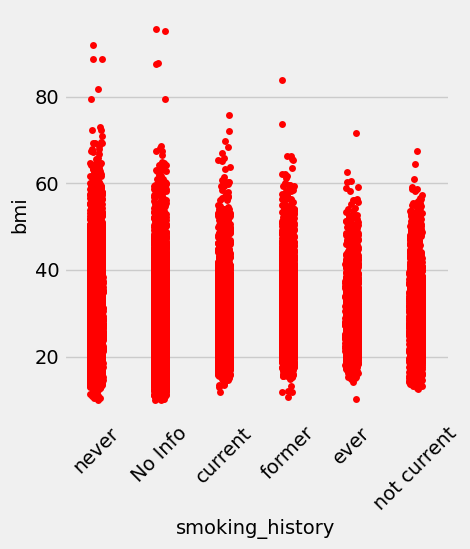

In [15]:
sns.catplot(x='smoking_history',y='bmi',kind='strip',data=df,color='red')
plt.xticks(rotation=45)
plt.show()

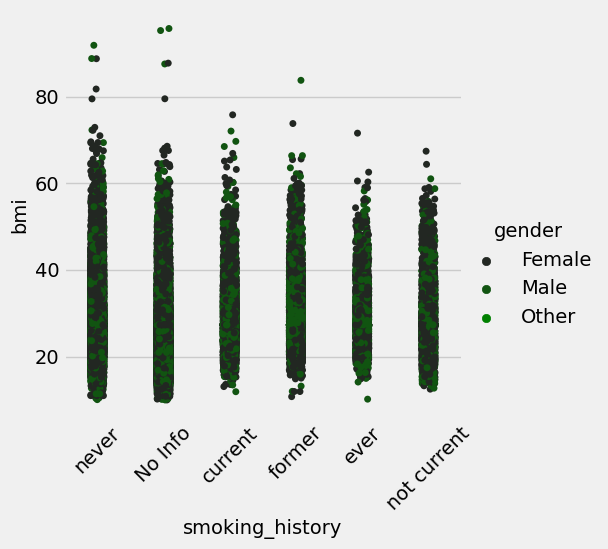

In [16]:
sns.catplot(x='smoking_history',y='bmi',hue='gender',data=df,color='green')
plt.xticks(rotation=45)
plt.show()

The 'bmi' rate of the non-smokers are more than that of smokers and they are mostly male. 

### Barplot

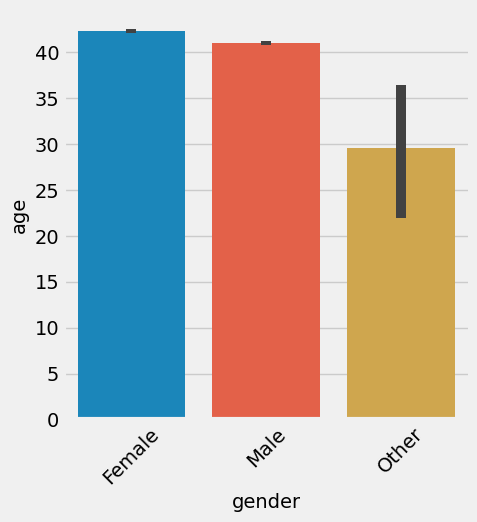

In [17]:
sns.catplot(x='gender',y='age',kind='bar',data=df)
plt.xticks(rotation=45)
plt.show()

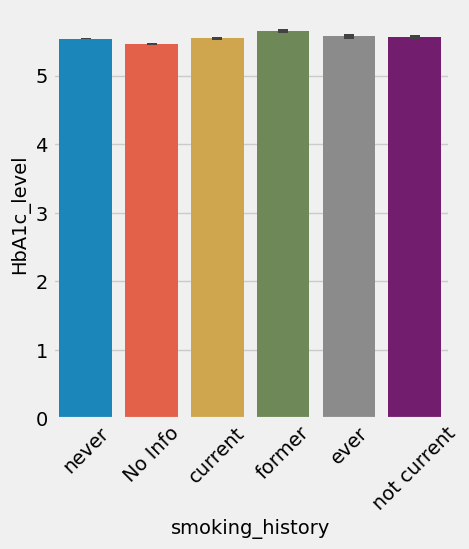

In [18]:
sns.catplot(x='smoking_history',y='HbA1c_level',data=df,kind='bar')
plt.xticks(rotation=45)
plt.show()

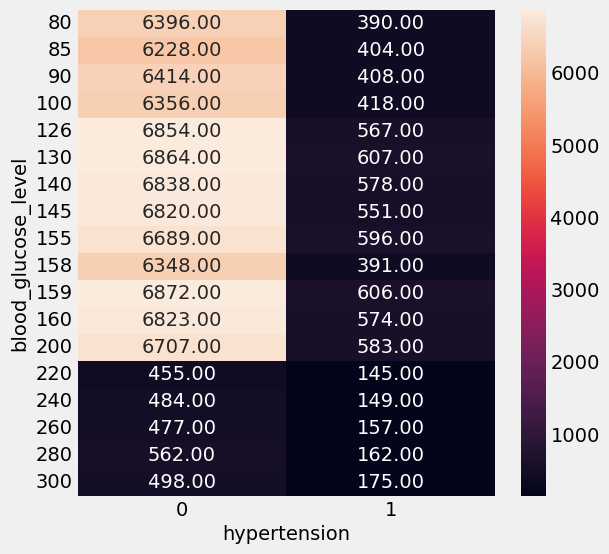

In [19]:
sns.heatmap(pd.crosstab(df['blood_glucose_level'],df['hypertension']),annot=True, fmt=".2f")
plt.show()

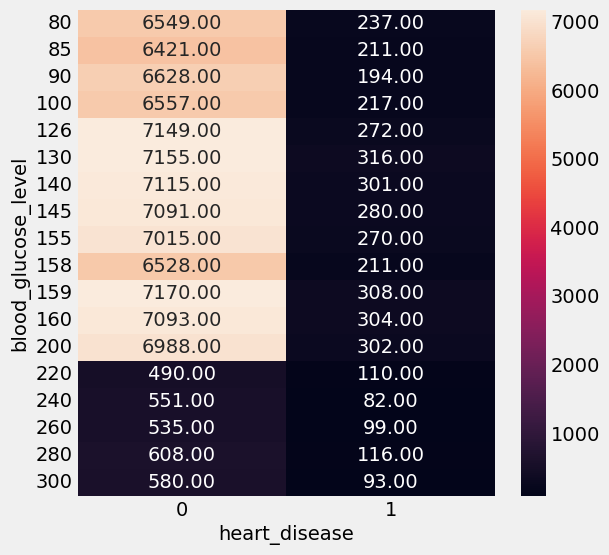

In [20]:
sns.heatmap(pd.crosstab(df['blood_glucose_level'],df['heart_disease']),annot=True, fmt=".2f")
plt.show()

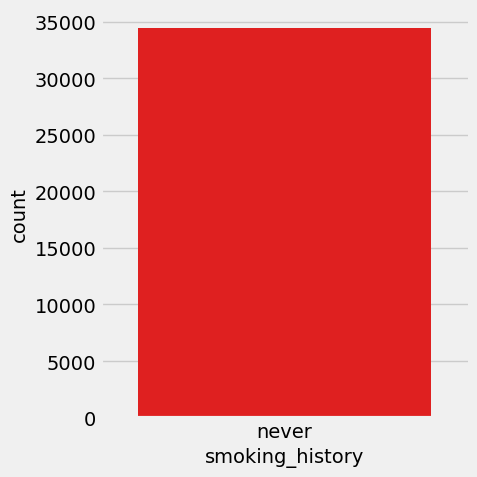

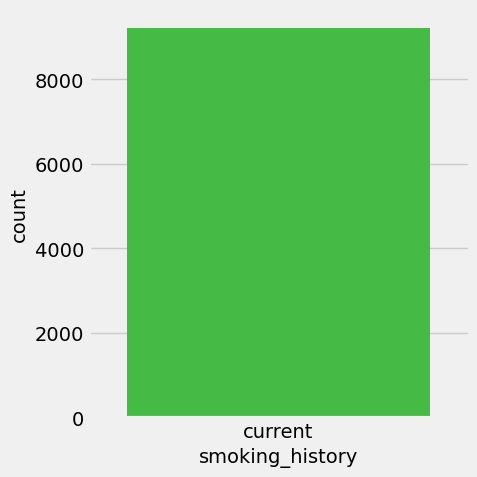

In [21]:
sns.catplot(x='smoking_history',kind='count',color='#FF0000',data=df[df['smoking_history']=='never'])

sns.catplot(x='smoking_history',kind='count',color='#32CD32',data=df[df['smoking_history']=='current'])
plt.show()

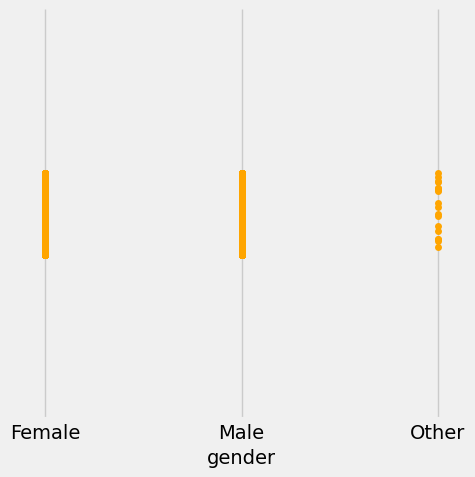

In [22]:
sns.catplot(x='gender',data=df,color='orange')
plt.show()

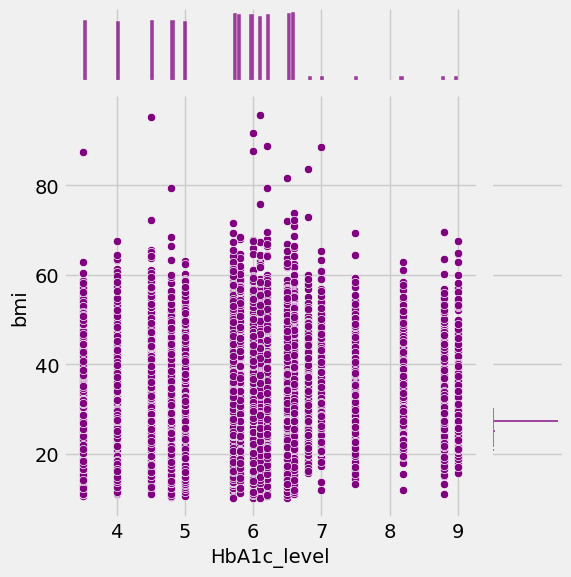

In [23]:
sns.jointplot(x='HbA1c_level',y='bmi',color='#800080',data=df)
plt.show()

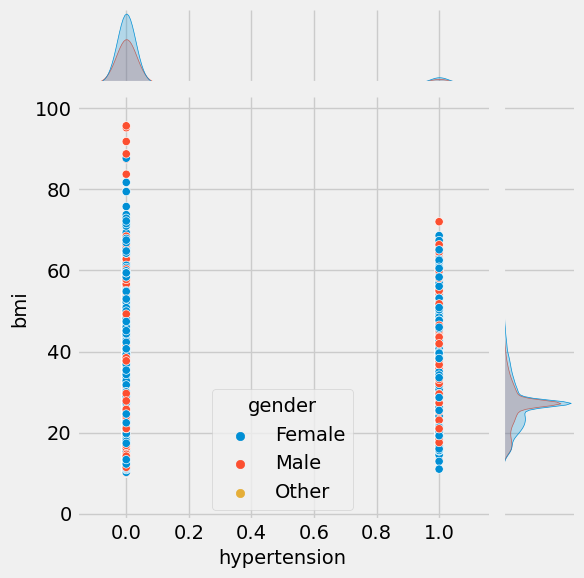

In [24]:
sns.jointplot(x='hypertension',y='bmi',hue='gender',color='#FFD700',data=df)
plt.show()

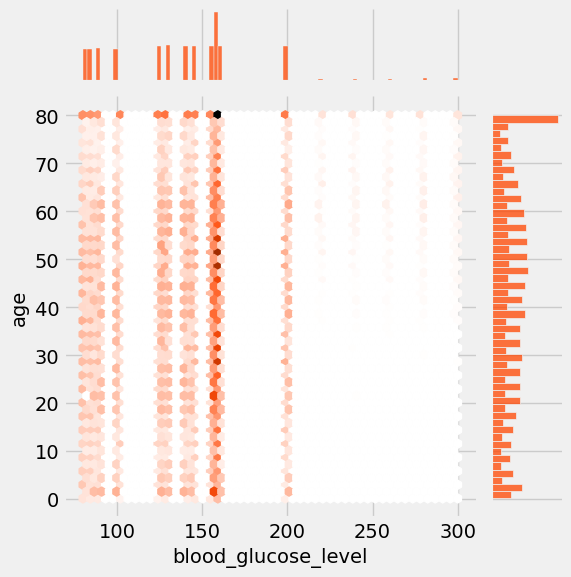

In [25]:
sns.jointplot(x='blood_glucose_level',y='age',kind='hex',color='#FF4500',data=df)
plt.show()

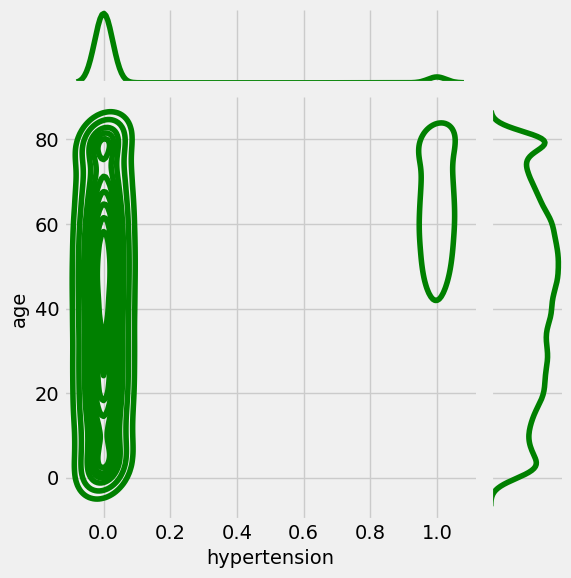

In [26]:
sns.jointplot(x='hypertension',y='age',kind='kde',color='green',data=df)
plt.show()

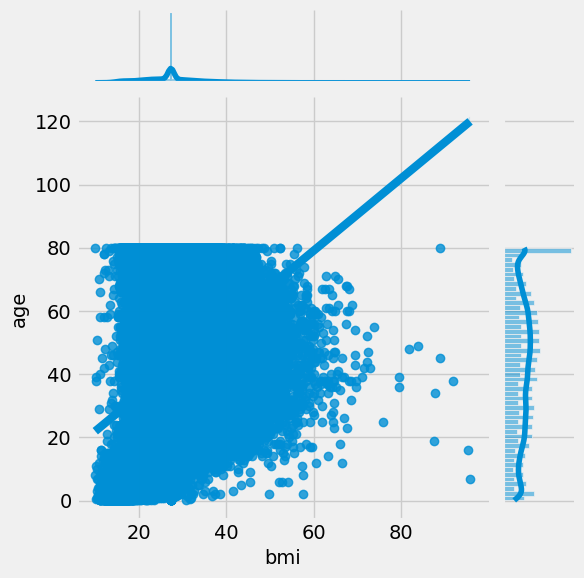

In [27]:
sns.jointplot(x='bmi',y='age',kind='reg',data=df)
plt.show()

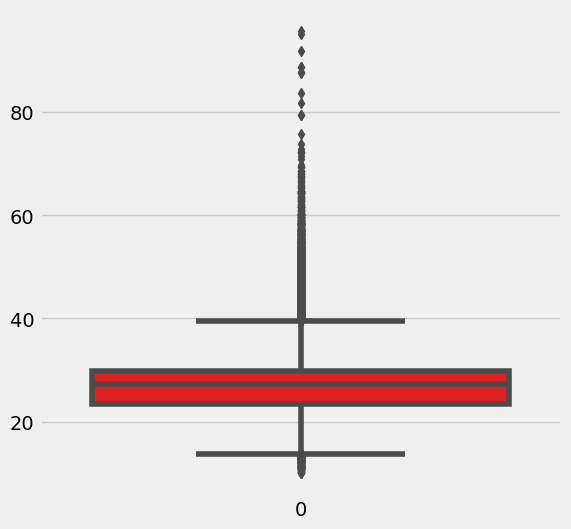

In [28]:
sns.boxplot(df['bmi'],color='#FF0000')
plt.show()

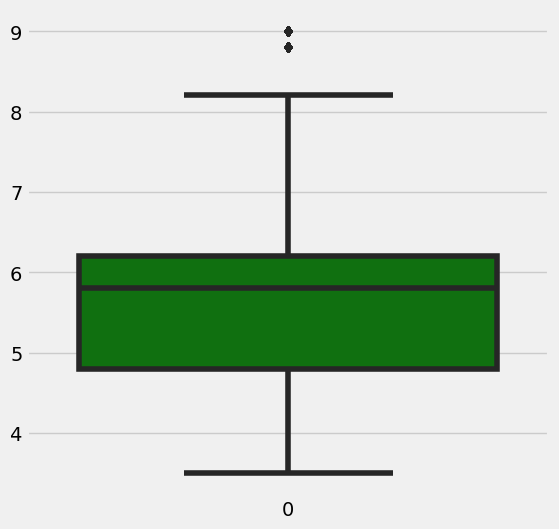

In [29]:
sns.boxplot(df['HbA1c_level'],color='green')
plt.show()

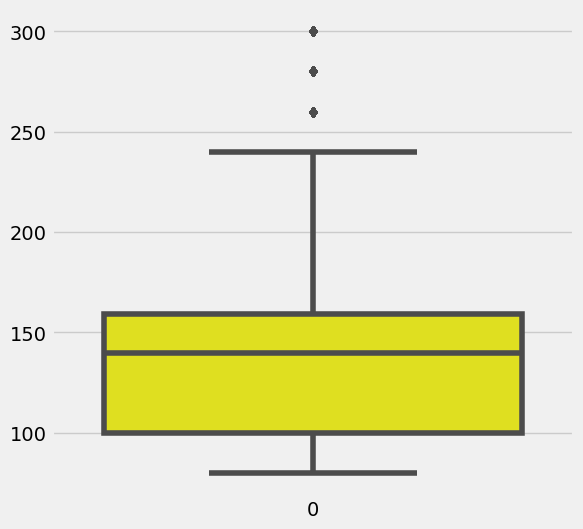

In [30]:
sns.boxplot(df['blood_glucose_level'],color='yellow')
plt.show()

### Removing the outliers

In [36]:
#Checking the statistical distribution of the BMI column

df3['bmi'].describe()

count    9.614600e+04
mean    -3.800804e-16
std      1.000005e+00
min     -2.557961e+00
25%     -5.794395e-01
50%     -2.158954e-04
75%      3.750973e-01
max      1.010221e+01
Name: bmi, dtype: float64

In [37]:
percentile25=df3['bmi'].quantile(0.25)
percentile75=df3['bmi'].quantile(0.75)

In [38]:
percentile25

-0.5794394681045526

In [39]:
percentile75

0.3750973378933778

In [40]:
iqr=percentile75-percentile25
iqr

0.9545368059979304

In [41]:
upper_limit=percentile75+1.5*iqr
lower_limit=percentile25-1.5*iqr
print("Upper Limit",upper_limit)
print("Lower Limit",lower_limit)

Upper Limit 1.8069025468902733
Lower Limit -2.0112446771014483


In [42]:
df3[df3['bmi']>upper_limit]
df3[df3['bmi']<lower_limit]
df3['bmi']=np.where(
                df3['bmi']>upper_limit,upper_limit,
                np.where(
                df3['bmi']<lower_limit,lower_limit,df3['bmi']
                ))

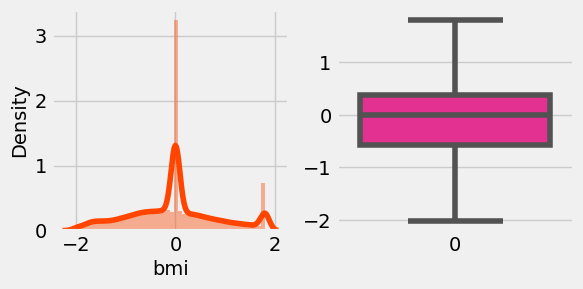

In [43]:
plt.subplot(2,2,1)
sns.distplot(df3['bmi'],color='#FF4500')
plt.subplot(2,2,2)
sns.boxplot(df3['bmi'],color='#FF1493')
plt.show()

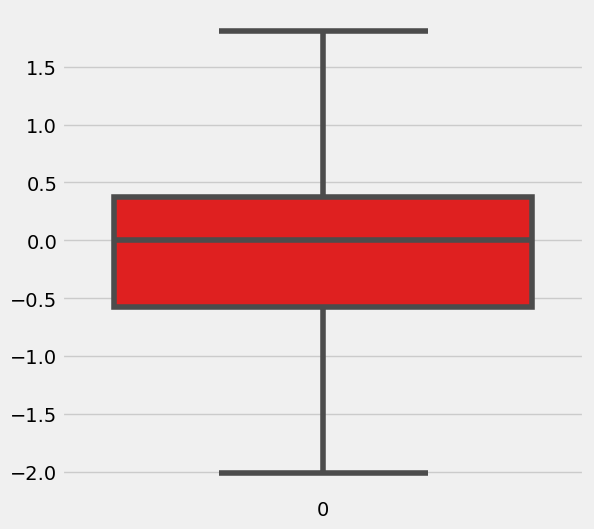

In [44]:
#Distribution of BMI after removing the outliers

sns.boxplot(df3['bmi'],color='#FF0000')
plt.show()

In [45]:
#Checking the statistical distribution of the BMI column

df3['blood_glucose_level'].describe()

count    9.614600e+04
mean    -8.129272e-17
std      1.000005e+00
min     -1.423096e+00
25%     -9.342127e-01
50%      4.355386e-02
75%      5.079930e-01
max      3.954620e+00
Name: blood_glucose_level, dtype: float64

In [46]:
percentile25=df3['blood_glucose_level'].quantile(0.25)
percentile75=df3['blood_glucose_level'].quantile(0.75)
iqr=percentile75-percentile25
iqr

1.4422057337909533

In [47]:
upper_limit=percentile75+1.5*iqr
lower_limit=percentile25-1.5*iqr
print("Upper Limit",upper_limit)
print("Lower Limit",lower_limit)

Upper Limit 2.671301600279909
Lower Limit -3.0975213348839046


In [48]:
df3[df3['blood_glucose_level']>upper_limit]
df3[df3['blood_glucose_level']<lower_limit]
df3['blood_glucose_level']=np.where(
                df3['blood_glucose_level']>upper_limit,upper_limit,
                np.where(
                df3['blood_glucose_level']<lower_limit,lower_limit,df3['blood_glucose_level']
                ))

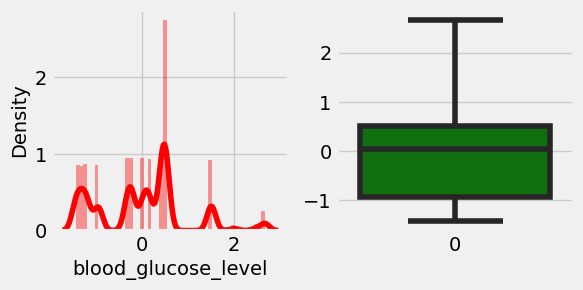

In [49]:
plt.subplot(2,2,1)
sns.distplot(df3['blood_glucose_level'],color='red')
plt.subplot(2,2,2)
sns.boxplot(df3['blood_glucose_level'],color='green')
plt.show()

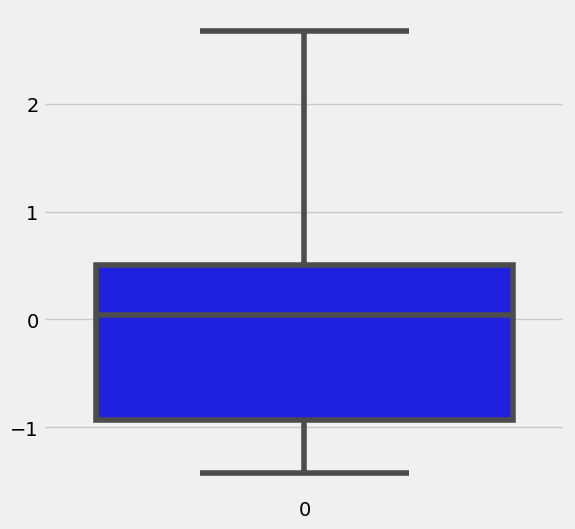

In [50]:
#Distribution of BMI after removing the outliers

sns.boxplot(df3['blood_glucose_level'],color='blue')
plt.show()

In [51]:
#Checking the statistical distribution of the BMI column

df3['HbA1c_level'].describe()

count    9.614600e+04
mean     2.397396e-16
std      1.000005e+00
min     -1.893923e+00
25%     -6.826227e-01
50%      2.491471e-01
75%      6.218550e-01
max      3.230810e+00
Name: HbA1c_level, dtype: float64

In [52]:
percentile25=df3['HbA1c_level'].quantile(0.25)
percentile75=df3['HbA1c_level'].quantile(0.75)
iqr=percentile75-percentile25
iqr

1.304477733797013

In [53]:
upper_limit=percentile75+1.5*iqr
lower_limit=percentile25-1.5*iqr
print("Upper Limit",upper_limit)
print("Lower Limit",lower_limit)

Upper Limit 2.578571627310942
Lower Limit -2.63933930787711


In [54]:
df3[df3['HbA1c_level']>upper_limit]
df3[df3['HbA1c_level']<lower_limit]
df3['HbA1c_level']=np.where(
                df3['HbA1c_level']>upper_limit,upper_limit,
                np.where(
                df3['HbA1c_level']<lower_limit,lower_limit,df3['HbA1c_level']
                ))

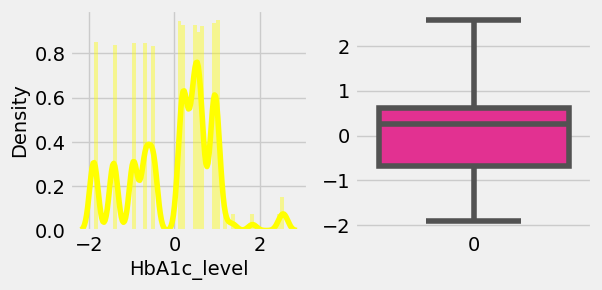

In [55]:
plt.subplot(2,2,1)
sns.distplot(df3['HbA1c_level'],color='#FFFF00')
plt.subplot(2,2,2)
sns.boxplot(df3['HbA1c_level'],color='#FF1493')
plt.show()

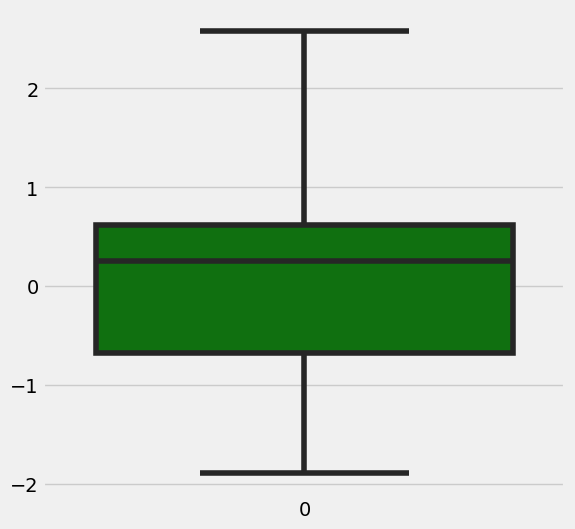

In [56]:
#Distribution of BMI after removing the outliers

sns.boxplot(df3['HbA1c_level'],color='green')
plt.show()

In [32]:
#Create a new dataframe with the columns of the original dataframe

df3=df[['age', 'hypertension', 'heart_disease','bmi', 'HbA1c_level', 'blood_glucose_level', 'diabetes']]
df3.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
0,80.0,0,1,25.19,6.6,140,0
1,54.0,0,0,27.32,6.6,80,0
2,28.0,0,0,27.32,5.7,158,0
3,36.0,0,0,23.45,5.0,155,0
4,76.0,1,1,20.14,4.8,155,0


In [33]:
#Checking the dataype of the features present in the new dataframe

df3.info()

<class 'pandas.core.frame.DataFrame'>
Index: 96146 entries, 0 to 99999
Data columns (total 7 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   age                  96146 non-null  float64
 1   hypertension         96146 non-null  int64  
 2   heart_disease        96146 non-null  int64  
 3   bmi                  96146 non-null  float64
 4   HbA1c_level          96146 non-null  float64
 5   blood_glucose_level  96146 non-null  int64  
 6   diabetes             96146 non-null  int64  
dtypes: float64(3), int64(4)
memory usage: 7.9 MB


In [34]:
scaler = StandardScaler()
df3[['age','bmi', 'HbA1c_level','blood_glucose_level']] = scaler.fit_transform(df3[['age','bmi', 'HbA1c_level','blood_glucose_level']])
print(df3)

            age  hypertension  heart_disease       bmi  HbA1c_level  \
0      1.700840             0              1 -0.314947     0.994563   
1      0.543372             0              0 -0.000216     0.994563   
2     -0.614096             0              0 -0.000216     0.155970   
3     -0.257952             0              0 -0.572051    -0.496269   
4      1.522768             1              1 -1.061141    -0.682623   
...         ...           ...            ...       ...          ...   
99994 -0.257952             0              0 -0.402126    -0.682623   
99996 -1.771563             0              0 -1.470439     0.901386   
99997  1.077588             0              0  0.075142     0.155970   
99998 -0.792168             0              0  1.196649    -1.428039   
99999  0.676926             0              0 -0.722768     0.994563   

       blood_glucose_level  diabetes  
0                 0.043554         0  
1                -1.423096         0  
2                 0.483549    

In [35]:
df3.shape

(96146, 7)

In [57]:
x=df3.drop(['diabetes'],axis='columns')
y=df3['diabetes']

### Train Test Split

In [58]:
X_train,X_test,y_train,y_test=train_test_split(x,y,test_size=0.2)

In [59]:
##GaussianNB model

gb=GaussianNB()
gb.fit(X_train,y_train)
y_pred=gb.predict(X_test)

In [60]:
##checking the accuracy

ac=accuracy_score(y_test,y_pred)
ac

0.9067082683307333

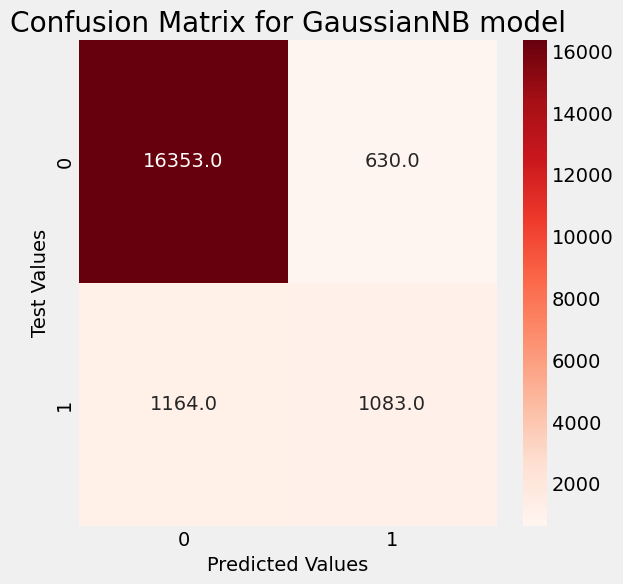

In [61]:
##confusion matrix

from sklearn.metrics import confusion_matrix
matrix=metrics.confusion_matrix(y_pred,y_test)
matrix=metrics.confusion_matrix(y_pred,y_test)
sns.heatmap(matrix,annot=True,cmap='Reds',fmt='0.1f')
plt.xlabel("Predicted Values")
plt.ylabel("Test Values")
plt.title("Confusion Matrix for GaussianNB model")
plt.show()

In [62]:
##Logistic Regression
lr=LogisticRegression()
lr.fit(X_train,y_train)
y_pred=lr.predict(X_test)

In [63]:
ac=accuracy_score(y_test,y_pred)
ac

0.9570982839313572

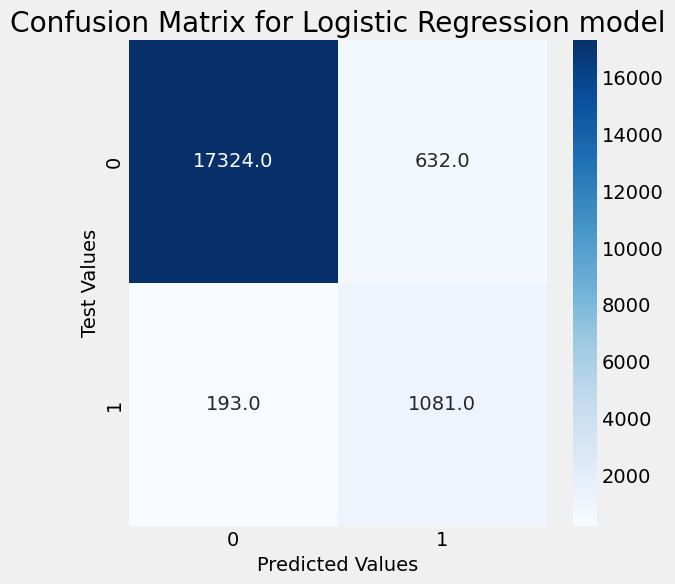

In [64]:
##confusion matrix

matrix=metrics.confusion_matrix(y_pred,y_test)
matrix=metrics.confusion_matrix(y_pred,y_test)
sns.heatmap(matrix,annot=True,cmap='Blues',fmt='0.1f')
plt.xlabel("Predicted Values")
plt.ylabel("Test Values")
plt.title("Confusion Matrix for Logistic Regression model")
plt.show()

In [65]:

knn=KNeighborsClassifier()
knn.fit(X_train,y_train)
y_pred=knn.predict(X_test)

In [66]:
##checking the accuracy


ac=accuracy_score(y_test,y_pred)
ac

0.9648985959438378

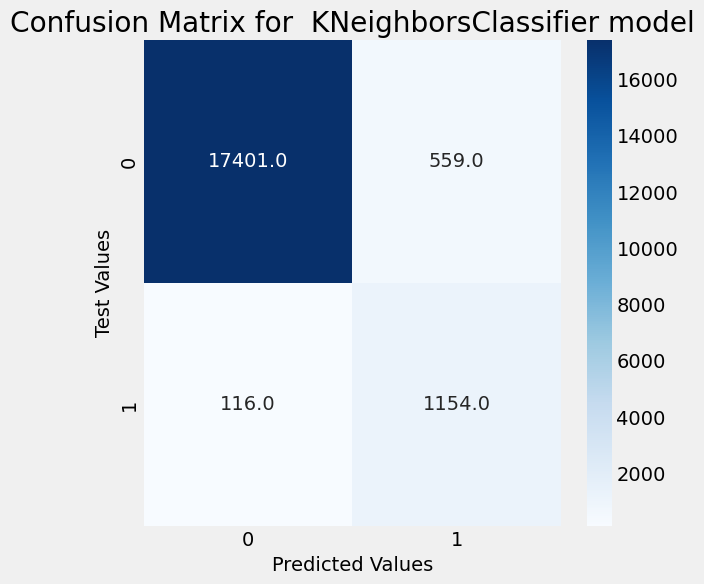

In [67]:
##confusion matrix


matrix=metrics.confusion_matrix(y_pred,y_test)
matrix=metrics.confusion_matrix(y_pred,y_test)
sns.heatmap(matrix,annot=True,cmap='Blues',fmt='0.1f')
plt.xlabel("Predicted Values")
plt.ylabel("Test Values")
plt.title("Confusion Matrix for  KNeighborsClassifier model")
plt.show()

In [68]:
dtc= DecisionTreeClassifier()
dtc.fit(X_train,y_train)
y_pred=dtc.predict(X_test)

In [69]:
##checking the accuracy


ac=accuracy_score(y_test,y_pred)
ac

0.9537701508060322

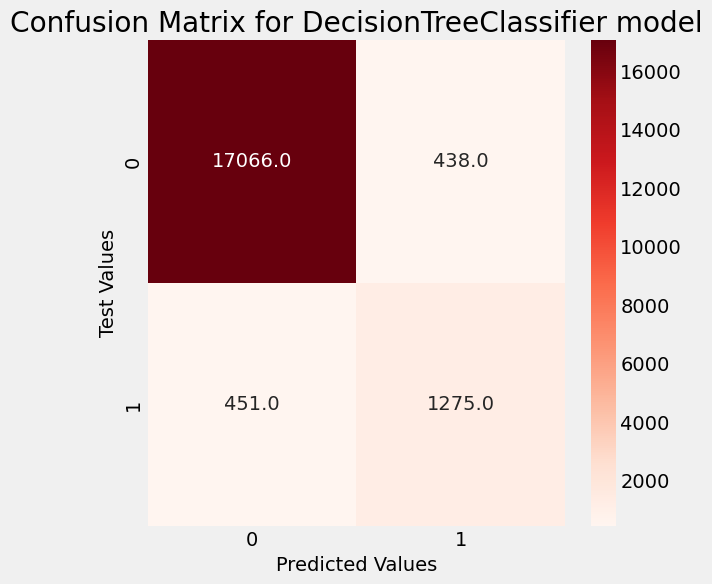

In [70]:
##confusion matrix


matrix=metrics.confusion_matrix(y_pred,y_test)
matrix=metrics.confusion_matrix(y_pred,y_test)
sns.heatmap(matrix,annot=True,cmap='Reds',fmt='0.1f')
plt.xlabel("Predicted Values")
plt.ylabel("Test Values")
plt.title("Confusion Matrix for DecisionTreeClassifier model")
plt.show()

In [71]:
##XGBoost Classifier

xgb=XGBClassifier()
xgb.fit(X_train,y_train)
y_pred=xgb.predict(X_test)

In [72]:
##checking the accuracy

ac=accuracy_score(y_test,y_pred)
ac

0.970826833073323

In [73]:
##confusion matrix

matrix=metrics.confusion_matrix(y_pred,y_test)
matrix

array([[17471,   515],
       [   46,  1198]], dtype=int64)

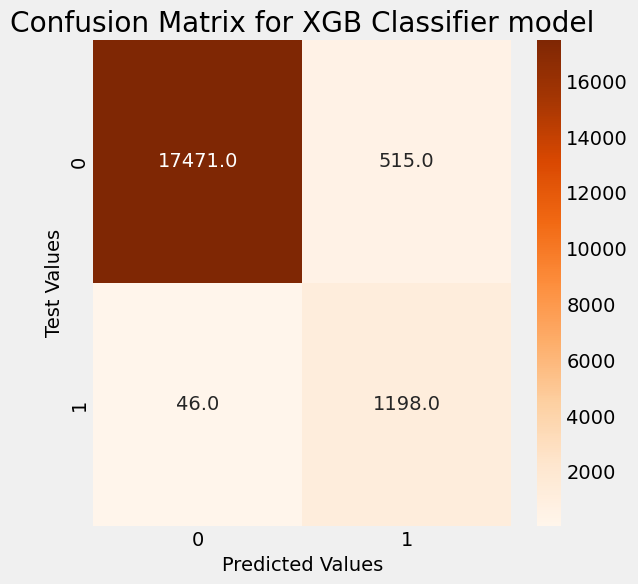

In [74]:
matrix=metrics.confusion_matrix(y_pred,y_test)
sns.heatmap(matrix,annot=True,cmap='Oranges',fmt='0.1f')
plt.xlabel("Predicted Values")
plt.ylabel("Test Values")
plt.title("Confusion Matrix for XGB Classifier model")
plt.show()

In [75]:
cb=CatBoostClassifier()
cb.fit(X_train,y_train)
y_pred=cb.predict(X_test)

Learning rate set to 0.065806
0:	learn: 0.5631222	total: 176ms	remaining: 2m 56s
1:	learn: 0.4765803	total: 194ms	remaining: 1m 36s
2:	learn: 0.4014417	total: 211ms	remaining: 1m 10s
3:	learn: 0.3491472	total: 226ms	remaining: 56.2s
4:	learn: 0.2859361	total: 241ms	remaining: 48s
5:	learn: 0.2381676	total: 256ms	remaining: 42.4s
6:	learn: 0.2014594	total: 270ms	remaining: 38.3s
7:	learn: 0.1783368	total: 286ms	remaining: 35.4s
8:	learn: 0.1612053	total: 302ms	remaining: 33.2s
9:	learn: 0.1433590	total: 317ms	remaining: 31.3s
10:	learn: 0.1348524	total: 337ms	remaining: 30.3s
11:	learn: 0.1252076	total: 351ms	remaining: 28.9s
12:	learn: 0.1175277	total: 367ms	remaining: 27.9s
13:	learn: 0.1118692	total: 382ms	remaining: 26.9s
14:	learn: 0.1076652	total: 396ms	remaining: 26s
15:	learn: 0.1042591	total: 415ms	remaining: 25.5s
16:	learn: 0.1014807	total: 433ms	remaining: 25.1s
17:	learn: 0.0996234	total: 449ms	remaining: 24.5s
18:	learn: 0.0972690	total: 465ms	remaining: 24s
19:	learn: 0.0

160:	learn: 0.0788250	total: 2.75s	remaining: 14.3s
161:	learn: 0.0787935	total: 2.77s	remaining: 14.3s
162:	learn: 0.0787637	total: 2.79s	remaining: 14.3s
163:	learn: 0.0787424	total: 2.8s	remaining: 14.3s
164:	learn: 0.0787342	total: 2.82s	remaining: 14.3s
165:	learn: 0.0787166	total: 2.83s	remaining: 14.2s
166:	learn: 0.0786891	total: 2.85s	remaining: 14.2s
167:	learn: 0.0786668	total: 2.87s	remaining: 14.2s
168:	learn: 0.0786312	total: 2.89s	remaining: 14.2s
169:	learn: 0.0786089	total: 2.9s	remaining: 14.2s
170:	learn: 0.0785680	total: 2.92s	remaining: 14.2s
171:	learn: 0.0785468	total: 2.94s	remaining: 14.1s
172:	learn: 0.0785073	total: 2.95s	remaining: 14.1s
173:	learn: 0.0784977	total: 2.97s	remaining: 14.1s
174:	learn: 0.0784806	total: 2.99s	remaining: 14.1s
175:	learn: 0.0784649	total: 3s	remaining: 14.1s
176:	learn: 0.0784371	total: 3.02s	remaining: 14s
177:	learn: 0.0784110	total: 3.04s	remaining: 14s
178:	learn: 0.0783819	total: 3.05s	remaining: 14s
179:	learn: 0.0783682	t

319:	learn: 0.0752314	total: 5.5s	remaining: 11.7s
320:	learn: 0.0752198	total: 5.53s	remaining: 11.7s
321:	learn: 0.0751947	total: 5.54s	remaining: 11.7s
322:	learn: 0.0751809	total: 5.56s	remaining: 11.6s
323:	learn: 0.0751546	total: 5.57s	remaining: 11.6s
324:	learn: 0.0751421	total: 5.59s	remaining: 11.6s
325:	learn: 0.0751146	total: 5.6s	remaining: 11.6s
326:	learn: 0.0750975	total: 5.62s	remaining: 11.6s
327:	learn: 0.0750930	total: 5.63s	remaining: 11.5s
328:	learn: 0.0750626	total: 5.64s	remaining: 11.5s
329:	learn: 0.0750382	total: 5.66s	remaining: 11.5s
330:	learn: 0.0750219	total: 5.67s	remaining: 11.5s
331:	learn: 0.0749971	total: 5.68s	remaining: 11.4s
332:	learn: 0.0749807	total: 5.7s	remaining: 11.4s
333:	learn: 0.0749660	total: 5.72s	remaining: 11.4s
334:	learn: 0.0749480	total: 5.74s	remaining: 11.4s
335:	learn: 0.0749327	total: 5.76s	remaining: 11.4s
336:	learn: 0.0749178	total: 5.77s	remaining: 11.4s
337:	learn: 0.0748999	total: 5.79s	remaining: 11.3s
338:	learn: 0.0

481:	learn: 0.0726433	total: 8.05s	remaining: 8.65s
482:	learn: 0.0726237	total: 8.07s	remaining: 8.63s
483:	learn: 0.0726112	total: 8.09s	remaining: 8.62s
484:	learn: 0.0725995	total: 8.1s	remaining: 8.6s
485:	learn: 0.0725776	total: 8.12s	remaining: 8.59s
486:	learn: 0.0725525	total: 8.13s	remaining: 8.57s
487:	learn: 0.0725292	total: 8.15s	remaining: 8.55s
488:	learn: 0.0725166	total: 8.17s	remaining: 8.53s
489:	learn: 0.0725016	total: 8.18s	remaining: 8.52s
490:	learn: 0.0724886	total: 8.2s	remaining: 8.5s
491:	learn: 0.0724754	total: 8.22s	remaining: 8.49s
492:	learn: 0.0724605	total: 8.24s	remaining: 8.47s
493:	learn: 0.0724527	total: 8.25s	remaining: 8.45s
494:	learn: 0.0724398	total: 8.27s	remaining: 8.44s
495:	learn: 0.0724294	total: 8.29s	remaining: 8.42s
496:	learn: 0.0724102	total: 8.3s	remaining: 8.4s
497:	learn: 0.0724000	total: 8.32s	remaining: 8.39s
498:	learn: 0.0723816	total: 8.34s	remaining: 8.37s
499:	learn: 0.0723679	total: 8.35s	remaining: 8.35s
500:	learn: 0.0723

647:	learn: 0.0701593	total: 10.6s	remaining: 5.77s
648:	learn: 0.0701425	total: 10.6s	remaining: 5.76s
649:	learn: 0.0701296	total: 10.7s	remaining: 5.74s
650:	learn: 0.0701154	total: 10.7s	remaining: 5.72s
651:	learn: 0.0701031	total: 10.7s	remaining: 5.71s
652:	learn: 0.0700994	total: 10.7s	remaining: 5.69s
653:	learn: 0.0700850	total: 10.7s	remaining: 5.67s
654:	learn: 0.0700745	total: 10.7s	remaining: 5.66s
655:	learn: 0.0700623	total: 10.8s	remaining: 5.64s
656:	learn: 0.0700501	total: 10.8s	remaining: 5.62s
657:	learn: 0.0700347	total: 10.8s	remaining: 5.6s
658:	learn: 0.0700206	total: 10.8s	remaining: 5.59s
659:	learn: 0.0700060	total: 10.8s	remaining: 5.57s
660:	learn: 0.0699930	total: 10.8s	remaining: 5.55s
661:	learn: 0.0699736	total: 10.8s	remaining: 5.54s
662:	learn: 0.0699678	total: 10.9s	remaining: 5.52s
663:	learn: 0.0699577	total: 10.9s	remaining: 5.5s
664:	learn: 0.0699462	total: 10.9s	remaining: 5.49s
665:	learn: 0.0699305	total: 10.9s	remaining: 5.47s
666:	learn: 0.

812:	learn: 0.0680029	total: 13.2s	remaining: 3.03s
813:	learn: 0.0679873	total: 13.2s	remaining: 3.01s
814:	learn: 0.0679721	total: 13.2s	remaining: 3s
815:	learn: 0.0679603	total: 13.2s	remaining: 2.98s
816:	learn: 0.0679505	total: 13.2s	remaining: 2.96s
817:	learn: 0.0679368	total: 13.3s	remaining: 2.95s
818:	learn: 0.0679277	total: 13.3s	remaining: 2.93s
819:	learn: 0.0679136	total: 13.3s	remaining: 2.92s
820:	learn: 0.0679028	total: 13.3s	remaining: 2.9s
821:	learn: 0.0678886	total: 13.3s	remaining: 2.88s
822:	learn: 0.0678778	total: 13.3s	remaining: 2.87s
823:	learn: 0.0678570	total: 13.4s	remaining: 2.85s
824:	learn: 0.0678371	total: 13.4s	remaining: 2.84s
825:	learn: 0.0678218	total: 13.4s	remaining: 2.82s
826:	learn: 0.0677989	total: 13.4s	remaining: 2.8s
827:	learn: 0.0677784	total: 13.4s	remaining: 2.79s
828:	learn: 0.0677603	total: 13.4s	remaining: 2.77s
829:	learn: 0.0677510	total: 13.5s	remaining: 2.75s
830:	learn: 0.0677355	total: 13.5s	remaining: 2.74s
831:	learn: 0.067

972:	learn: 0.0660243	total: 18s	remaining: 498ms
973:	learn: 0.0660164	total: 18s	remaining: 481ms
974:	learn: 0.0660086	total: 18s	remaining: 463ms
975:	learn: 0.0659999	total: 18.1s	remaining: 444ms
976:	learn: 0.0659880	total: 18.1s	remaining: 426ms
977:	learn: 0.0659798	total: 18.1s	remaining: 408ms
978:	learn: 0.0659730	total: 18.2s	remaining: 390ms
979:	learn: 0.0659637	total: 18.2s	remaining: 372ms
980:	learn: 0.0659502	total: 18.3s	remaining: 353ms
981:	learn: 0.0659352	total: 18.3s	remaining: 335ms
982:	learn: 0.0659229	total: 18.3s	remaining: 317ms
983:	learn: 0.0659084	total: 18.4s	remaining: 298ms
984:	learn: 0.0659047	total: 18.4s	remaining: 280ms
985:	learn: 0.0658862	total: 18.4s	remaining: 262ms
986:	learn: 0.0658812	total: 18.5s	remaining: 243ms
987:	learn: 0.0658704	total: 18.5s	remaining: 225ms
988:	learn: 0.0658570	total: 18.5s	remaining: 206ms
989:	learn: 0.0658516	total: 18.6s	remaining: 188ms
990:	learn: 0.0658445	total: 18.6s	remaining: 169ms
991:	learn: 0.0658

In [76]:
##checking the accuracy


ac=accuracy_score(y_test,y_pred)
ac

0.971086843473739

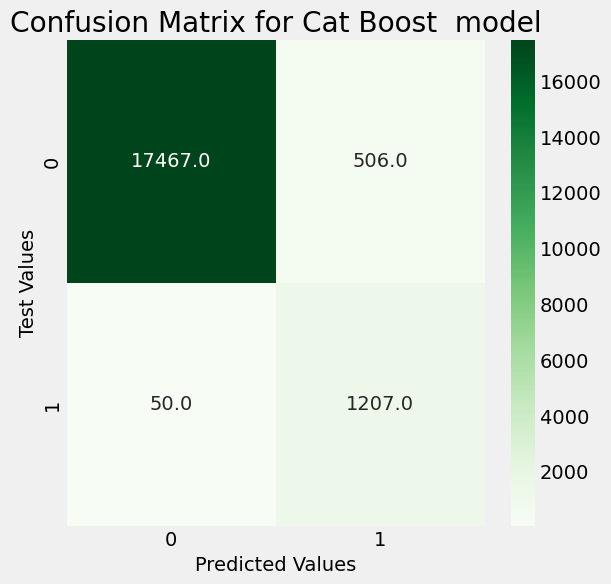

In [77]:
##confusion matrix


matrix=metrics.confusion_matrix(y_pred,y_test)
matrix=metrics.confusion_matrix(y_pred,y_test)
sns.heatmap(matrix,annot=True,cmap='Greens',fmt='0.1f')
plt.xlabel("Predicted Values")
plt.ylabel("Test Values")
plt.title("Confusion Matrix for Cat Boost  model")
plt.show()

In [78]:
model_accuracies = {}

# List of models to evaluate
models = [
    ('GaussianNB',GaussianNB()),
    ('Logistic Regression',LogisticRegression()),
   ('K Neighbors Classifier',KNeighborsClassifier()), 
    ('Decission Tree Classifier', DecisionTreeClassifier()),
    ('XG Boost',XGBClassifier()),
    ('Cat Boost',CatBoostClassifier()),
]

# Train and evaluate each model
for name, model in models:
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    accuracy = accuracy_score(y_test, y_pred)
    model_accuracies[name] = accuracy

# Create a DataFrame for better visualization
accuracy_df = pd.DataFrame(list(model_accuracies.items()), columns=['Model', 'Accuracy'])

Learning rate set to 0.065806
0:	learn: 0.5631222	total: 22.1ms	remaining: 22.1s
1:	learn: 0.4765803	total: 38.4ms	remaining: 19.2s
2:	learn: 0.4014417	total: 54.3ms	remaining: 18s
3:	learn: 0.3491472	total: 67.2ms	remaining: 16.7s
4:	learn: 0.2859361	total: 81.5ms	remaining: 16.2s
5:	learn: 0.2381676	total: 94.4ms	remaining: 15.6s
6:	learn: 0.2014594	total: 107ms	remaining: 15.2s
7:	learn: 0.1783368	total: 122ms	remaining: 15.2s
8:	learn: 0.1612053	total: 135ms	remaining: 14.9s
9:	learn: 0.1433590	total: 149ms	remaining: 14.8s
10:	learn: 0.1348524	total: 165ms	remaining: 14.8s
11:	learn: 0.1252076	total: 178ms	remaining: 14.7s
12:	learn: 0.1175277	total: 193ms	remaining: 14.7s
13:	learn: 0.1118692	total: 215ms	remaining: 15.1s
14:	learn: 0.1076652	total: 230ms	remaining: 15.1s
15:	learn: 0.1042591	total: 243ms	remaining: 15s
16:	learn: 0.1014807	total: 258ms	remaining: 14.9s
17:	learn: 0.0996234	total: 272ms	remaining: 14.8s
18:	learn: 0.0972690	total: 285ms	remaining: 14.7s
19:	learn

165:	learn: 0.0787166	total: 2.59s	remaining: 13s
166:	learn: 0.0786891	total: 2.61s	remaining: 13s
167:	learn: 0.0786668	total: 2.62s	remaining: 13s
168:	learn: 0.0786312	total: 2.64s	remaining: 13s
169:	learn: 0.0786089	total: 2.66s	remaining: 13s
170:	learn: 0.0785680	total: 2.67s	remaining: 13s
171:	learn: 0.0785468	total: 2.69s	remaining: 12.9s
172:	learn: 0.0785073	total: 2.7s	remaining: 12.9s
173:	learn: 0.0784977	total: 2.72s	remaining: 12.9s
174:	learn: 0.0784806	total: 2.73s	remaining: 12.9s
175:	learn: 0.0784649	total: 2.74s	remaining: 12.8s
176:	learn: 0.0784371	total: 2.76s	remaining: 12.8s
177:	learn: 0.0784110	total: 2.77s	remaining: 12.8s
178:	learn: 0.0783819	total: 2.79s	remaining: 12.8s
179:	learn: 0.0783682	total: 2.8s	remaining: 12.8s
180:	learn: 0.0783478	total: 2.82s	remaining: 12.8s
181:	learn: 0.0783204	total: 2.84s	remaining: 12.7s
182:	learn: 0.0783033	total: 2.85s	remaining: 12.7s
183:	learn: 0.0782899	total: 2.86s	remaining: 12.7s
184:	learn: 0.0782659	tota

324:	learn: 0.0751421	total: 5.01s	remaining: 10.4s
325:	learn: 0.0751146	total: 5.03s	remaining: 10.4s
326:	learn: 0.0750975	total: 5.04s	remaining: 10.4s
327:	learn: 0.0750930	total: 5.06s	remaining: 10.4s
328:	learn: 0.0750626	total: 5.07s	remaining: 10.3s
329:	learn: 0.0750382	total: 5.09s	remaining: 10.3s
330:	learn: 0.0750219	total: 5.1s	remaining: 10.3s
331:	learn: 0.0749971	total: 5.12s	remaining: 10.3s
332:	learn: 0.0749807	total: 5.13s	remaining: 10.3s
333:	learn: 0.0749660	total: 5.15s	remaining: 10.3s
334:	learn: 0.0749480	total: 5.16s	remaining: 10.3s
335:	learn: 0.0749327	total: 5.18s	remaining: 10.2s
336:	learn: 0.0749178	total: 5.19s	remaining: 10.2s
337:	learn: 0.0748999	total: 5.21s	remaining: 10.2s
338:	learn: 0.0748872	total: 5.23s	remaining: 10.2s
339:	learn: 0.0748740	total: 5.25s	remaining: 10.2s
340:	learn: 0.0748533	total: 5.27s	remaining: 10.2s
341:	learn: 0.0748407	total: 5.29s	remaining: 10.2s
342:	learn: 0.0748182	total: 5.31s	remaining: 10.2s
343:	learn: 0

486:	learn: 0.0725525	total: 10.2s	remaining: 10.8s
487:	learn: 0.0725292	total: 10.3s	remaining: 10.8s
488:	learn: 0.0725166	total: 10.3s	remaining: 10.8s
489:	learn: 0.0725016	total: 10.3s	remaining: 10.8s
490:	learn: 0.0724886	total: 10.4s	remaining: 10.8s
491:	learn: 0.0724754	total: 10.4s	remaining: 10.8s
492:	learn: 0.0724605	total: 10.5s	remaining: 10.8s
493:	learn: 0.0724527	total: 10.5s	remaining: 10.8s
494:	learn: 0.0724398	total: 10.6s	remaining: 10.8s
495:	learn: 0.0724294	total: 10.6s	remaining: 10.8s
496:	learn: 0.0724102	total: 10.6s	remaining: 10.8s
497:	learn: 0.0724000	total: 10.7s	remaining: 10.8s
498:	learn: 0.0723816	total: 10.7s	remaining: 10.7s
499:	learn: 0.0723679	total: 10.7s	remaining: 10.7s
500:	learn: 0.0723531	total: 10.8s	remaining: 10.7s
501:	learn: 0.0723432	total: 10.8s	remaining: 10.7s
502:	learn: 0.0723308	total: 10.8s	remaining: 10.7s
503:	learn: 0.0723025	total: 10.9s	remaining: 10.7s
504:	learn: 0.0722844	total: 10.9s	remaining: 10.7s
505:	learn: 

649:	learn: 0.0701296	total: 15.8s	remaining: 8.49s
650:	learn: 0.0701154	total: 15.8s	remaining: 8.48s
651:	learn: 0.0701031	total: 15.8s	remaining: 8.46s
652:	learn: 0.0700994	total: 15.9s	remaining: 8.44s
653:	learn: 0.0700850	total: 15.9s	remaining: 8.42s
654:	learn: 0.0700745	total: 15.9s	remaining: 8.4s
655:	learn: 0.0700623	total: 16s	remaining: 8.38s
656:	learn: 0.0700501	total: 16s	remaining: 8.37s
657:	learn: 0.0700347	total: 16.1s	remaining: 8.35s
658:	learn: 0.0700206	total: 16.1s	remaining: 8.33s
659:	learn: 0.0700060	total: 16.1s	remaining: 8.31s
660:	learn: 0.0699930	total: 16.2s	remaining: 8.29s
661:	learn: 0.0699736	total: 16.2s	remaining: 8.28s
662:	learn: 0.0699678	total: 16.3s	remaining: 8.27s
663:	learn: 0.0699577	total: 16.3s	remaining: 8.25s
664:	learn: 0.0699462	total: 16.4s	remaining: 8.24s
665:	learn: 0.0699305	total: 16.4s	remaining: 8.23s
666:	learn: 0.0699188	total: 16.5s	remaining: 8.21s
667:	learn: 0.0698943	total: 16.5s	remaining: 8.2s
668:	learn: 0.0698

812:	learn: 0.0680029	total: 21.2s	remaining: 4.87s
813:	learn: 0.0679873	total: 21.3s	remaining: 4.86s
814:	learn: 0.0679721	total: 21.3s	remaining: 4.83s
815:	learn: 0.0679603	total: 21.3s	remaining: 4.8s
816:	learn: 0.0679505	total: 21.3s	remaining: 4.78s
817:	learn: 0.0679368	total: 21.4s	remaining: 4.75s
818:	learn: 0.0679277	total: 21.4s	remaining: 4.73s
819:	learn: 0.0679136	total: 21.4s	remaining: 4.7s
820:	learn: 0.0679028	total: 21.5s	remaining: 4.68s
821:	learn: 0.0678886	total: 21.5s	remaining: 4.65s
822:	learn: 0.0678778	total: 21.5s	remaining: 4.63s
823:	learn: 0.0678570	total: 21.6s	remaining: 4.6s
824:	learn: 0.0678371	total: 21.6s	remaining: 4.58s
825:	learn: 0.0678218	total: 21.6s	remaining: 4.55s
826:	learn: 0.0677989	total: 21.7s	remaining: 4.53s
827:	learn: 0.0677784	total: 21.7s	remaining: 4.5s
828:	learn: 0.0677603	total: 21.7s	remaining: 4.48s
829:	learn: 0.0677510	total: 21.7s	remaining: 4.45s
830:	learn: 0.0677355	total: 21.8s	remaining: 4.43s
831:	learn: 0.06

971:	learn: 0.0660317	total: 26s	remaining: 748ms
972:	learn: 0.0660243	total: 26s	remaining: 721ms
973:	learn: 0.0660164	total: 26s	remaining: 695ms
974:	learn: 0.0660086	total: 26.1s	remaining: 668ms
975:	learn: 0.0659999	total: 26.1s	remaining: 641ms
976:	learn: 0.0659880	total: 26.1s	remaining: 615ms
977:	learn: 0.0659798	total: 26.1s	remaining: 588ms
978:	learn: 0.0659730	total: 26.2s	remaining: 561ms
979:	learn: 0.0659637	total: 26.2s	remaining: 535ms
980:	learn: 0.0659502	total: 26.2s	remaining: 508ms
981:	learn: 0.0659352	total: 26.3s	remaining: 481ms
982:	learn: 0.0659229	total: 26.3s	remaining: 454ms
983:	learn: 0.0659084	total: 26.3s	remaining: 428ms
984:	learn: 0.0659047	total: 26.3s	remaining: 401ms
985:	learn: 0.0658862	total: 26.4s	remaining: 374ms
986:	learn: 0.0658812	total: 26.4s	remaining: 348ms
987:	learn: 0.0658704	total: 26.4s	remaining: 321ms
988:	learn: 0.0658570	total: 26.5s	remaining: 294ms
989:	learn: 0.0658516	total: 26.5s	remaining: 268ms
990:	learn: 0.0658

In [79]:
accuracy_df.style.background_gradient()

,Model,Accuracy
0,GaussianNB,0.906708
1,Logistic Regression,0.957098
2,K Neighbors Classifier,0.964899
3,Decission Tree Classifier,0.953198
4,XG Boost,0.970827
5,Cat Boost,0.971087


In [81]:
model = XGBClassifier()
model.fit(X_train, y_train)

# Save the model as a pickle file
with open('Diabetes Prediction.pkl', 'wb') as file:
    pickle.dump(model, file)

# Load the saved model
with open('Diabetes Prediction.pkl', 'rb') as file:
    loaded_model = pickle.load(file)

# Function for prediction with user input
def predict_diabetes(age, hypertension, heart_disease,bmi, HbA1c_level, blood_glucose_level):
    input_data = [[age, hypertension, heart_disease,bmi, HbA1c_level, blood_glucose_level]]
    predicted = loaded_model.predict(input_data)[0]
    return predicted

# Example usage
predicted_result = predict_diabetes(1.70084,1,1,-0.314947,1.994563,1.043554)
print("Predicted Diabetes:", predicted_result)

Predicted Diabetes: 1
